11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Forma del X_train:  (60000, 28, 28)
Forma del y_train:  (60000,)


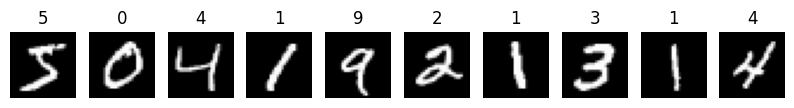

In [ ]:
#importamos las dependencias para mostrar los datos
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# Cargar solo los datos de entrenamiento
(X_train, y_train), _ = mnist.load_data()

print("Forma del X_train: ", X_train.shape)
print("Forma del y_train: ", y_train.shape)

#Mostrar las 10 primeras imágenes
plt.figure(figsize=(10,2))
for i in range(10):
    plt.subplot(1,10,i+1)
    plt.imshow(X_train[i], cmap='gray') #dibuja la imagen
    plt.axis('off')
    plt.title(str(y_train[i])) #coloca el número real

In [ ]:
#importar las dependencias de keras
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

# 1. cargar los datos (train solamente, para simplificar), luego normalizar
(x_train, y_train), _ = mnist.load_data()
x_train = x_train / 255 # recordar que los datos van de 0 a 255, y al dividir quedaría de 0 a 1

# 2. codificar etiquetas en one-hot
y_train = to_categorical(y_train, num_classes=10)

# 3. definir el modelo secuencial
model = Sequential(
    [
        Flatten(input_shape=(28,28)),
        Dense(128, activation='relu'),
        Dense(10, activation='softmax')
    ]
)

# 4. compilar el modelo
model.compile(
    optimizer='adam', # podemos usar otros como e descenso de gradiente (sgd)
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 5. entrenar el modelo
model.fit(
    x_train,
    y_train,
    epochs=10
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8760 - loss: 0.4354
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.9657 - loss: 0.1217
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9764 - loss: 0.0793
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9835 - loss: 0.0557
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9868 - loss: 0.0435
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9894 - loss: 0.0344
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9912 - loss: 0.0282
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9945 - loss: 0.0181
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9952 - loss: 0.0158
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9962 - loss: 0.0123


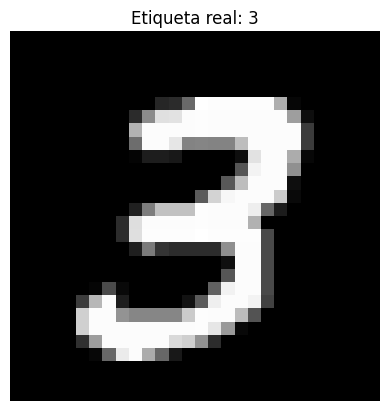

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Etiqueta predicha por el modelo: 3


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# escoger una imagen del conjunto de entrenamiento

indice = 7
imgen = x_train[indice] # imagen original (28x28)
etiqueta_esperada = np.argmax(y_train[indice]) # valor real

# mostrar imgen
plt.imshow(imgen, cmap='gray')
plt.title(f"Etiqueta real: {etiqueta_esperada}")
plt.axis('off')
plt.show()

# añadir dimensiónextra para simular batch de 1 imagen: (28, 28) --> (1, 28, 28)
imagen_input = np.expand_dims(imgen, axis=0)

# predecir
prediccion = model.predict(imagen_input)
clase_predicha = np.argmax(prediccion)

print(f"Etiqueta predicha por el modelo: {clase_predicha}")